# GRPO Training for Methanol APC Environment

**Goal**: Train an LLM to act as an autonomous Advanced Process Control (APC) operator for a methanol synthesis reactor using Group Relative Policy Optimization (GRPO).

**Architecture**: `LLM generates JSON action` → `MethanolRewardFunction parses & scores` → `env.step()` → `multi-component reward back to GRPO`

**Key design choices** (per OpenEnv GRPO guidelines):
- **Curriculum learning**: Train on easy tasks first (`startup`), then medium (`optimization`), then hard (`disturbance_rejection`)
- **Multi-component reward**: Physics reward + format compliance + safety bonus + economic signal
- **Deterministic replay**: Each prompt stores `(task, seed, num_warmup)` so all group completions see identical env state

**Environment**: [HF Space](https://huggingface.co/spaces/glitchfilter/methanol-apc-env) | [GitHub](https://github.com/Bhavneet1492/openenv-methanol-apc)

---
## 1. Setup and Dependencies

In [1]:
%%capture
# Install dependencies (run once on Colab)
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "trl>=0.15" "peft" "accelerate" "bitsandbytes"
!pip install "openenv-core[core]>=0.2.2" numpy matplotlib

# Clone the methanol APC repo for environment code
!git clone https://github.com/Bhavneet1492/openenv-methanol-apc.git /content/methanol-apc 2>/dev/null || true
import sys
sys.path.insert(0, "/content/methanol-apc")

In [2]:
import json, os, re, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
from unsloth import FastLanguageModel
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset

warnings.filterwarnings("ignore", category=UserWarning)

# Verify GPU and detect capabilities
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    USE_BF16 = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name} | VRAM: {vram_gb:.1f} GB | bf16: {USE_BF16}")
else:
    USE_BF16 = False
    print("WARNING: No GPU detected — training will be extremely slow")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: Tesla T4 | VRAM: 15.6 GB | bf16: False


## 2. Configuration and Constants

Hyperparameters tuned for Colab T4/A100. Key decisions:
- **Qwen2.5-3B** for faster iterations (switch to 7B if you have ≥24GB VRAM)
- **Curriculum**: 40% startup (easy) → 35% optimization (medium) → 25% disturbance (hard)
- **Group size 8**: More completions per prompt = better GRPO advantage estimation
- **Conservative LR with warmup**: Prevents early divergence in RL

In [3]:
# === Model Configuration ===
# Use 3B for Colab T4 (16GB); switch to 7B for A100/H100 (≥24GB)
MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
# MODEL_NAME = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"  # Uncomment for ≥24GB VRAM
MAX_SEQ_LENGTH = 2048
LORA_R = 16
LORA_ALPHA = 32
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",
                       "gate_proj", "up_proj", "down_proj"]

# === Training Configuration ===
NUM_TRAIN_STEPS = 200        # Enough steps to show clear improvement curve
GROUP_SIZE = 8               # GRPO group size — more = better advantage estimates
BATCH_SIZE = 2               # Per-device batch size
GRAD_ACCUM = 4               # Effective batch = 2 * 4 = 8 prompts × 8 completions = 64 fwd passes
LEARNING_RATE = 5e-6         # Conservative for RL — avoids catastrophic forgetting
WARMUP_RATIO = 0.05          # 5% warmup steps for stable early training
MAX_GRAD_NORM = 1.0          # Gradient clipping — critical for RL stability
MAX_COMPLETION_LENGTH = 120  # JSON actions are ~50-80 tokens; leave margin for fences/reasoning
TEMPERATURE = 0.7            # Exploration temperature during generation
KL_COEF = 0.05               # KL penalty to prevent mode collapse away from base model

# === Environment Configuration ===
# Curriculum: easy tasks first (higher weight), harder tasks later
TASK_CURRICULUM = {
    "startup": 0.40,               # Easy: ramp reactor to operating temp
    "optimization": 0.35,          # Medium: maximize profit at steady state
    "disturbance_rejection": 0.25, # Hard: handle cooling system failure
}
TASKS = list(TASK_CURRICULUM.keys())
STEPS_PER_EPISODE = 20       # Short episodes for fast training signal
NUM_PROMPTS = 300            # Total prompt dataset size (more = more diverse states)

# === Paths ===
PLOT_DIR = "/content/methanol-apc/training_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# === System Prompt (shared across all tasks) ===
SYSTEM_PROMPT = """You are an AI controller for a methanol synthesis reactor (ICI Low-Pressure Process, Cu/ZnO/Al₂O₃ catalyst).
Given sensor readings, output a JSON control action with these 4 fields:
{"feed_rate_h2": <0-10>, "feed_rate_co": <0-5>, "cooling_water_flow": <0-100>, "compressor_power": <0-100>}

PHYSICS RULES:
- CO + 2H₂ → CH₃OH is exothermic (ΔH = -90.5 kJ/mol). More feed = more heat + methanol.
- CO₂ + 3H₂ → CH₃OH + H₂O is secondary (ΔH = -49.5 kJ/mol).
- Optimal temperature: 240-260°C. Above 270°C = catalyst sintering. Above 300°C = EMERGENCY SHUTDOWN.
- Ideal H₂/CO ratio = 2.0 (stoichiometric). Deviation reduces conversion.
- Higher pressure (compressor_power) = faster reaction but more energy cost.
- Cooling water removes heat: increase flow when temperature rises, decrease when stable.

ECONOMIC RULES:
- Revenue: methanol_kg × $0.74/kg.  Costs: feed + electricity + cooling.
- Maximize profit = revenue - operating costs.

OUTPUT: Respond with ONLY the JSON object. No explanation, no markdown fences."""

print(f"Config: {MODEL_NAME}")
print(f"Training: {NUM_TRAIN_STEPS} steps, group_size={GROUP_SIZE}, batch={BATCH_SIZE}×{GRAD_ACCUM}")
print(f"Curriculum: {TASK_CURRICULUM}")

Config: unsloth/Qwen2.5-3B-Instruct-bnb-4bit
Training: 200 steps, group_size=8, batch=2×4
Curriculum: {'startup': 0.4, 'optimization': 0.35, 'disturbance_rejection': 0.25}


## 3. Helper Functions: Environment, Reward, and Prompts

In [ ]:
# --- Environment wrapper (runs locally) ---
from methanol_apc_env.server.methanol_environment import MethanolAPCEnvironment
from methanol_apc_env.models import MethanolAPCAction

def make_env(task="optimization", seed=42):
    """Create a fresh environment instance for a given task."""
    env = MethanolAPCEnvironment()
    obs = env.reset(task_name=task, seed=seed)
    return env, obs

def obs_to_text(obs):
    """Convert observation to a compact sensor-reading string for the LLM prompt."""
    return (
        f"T={obs.temperature:.1f}°C P={obs.pressure:.1f}bar "
        f"H2={obs.feed_rate_h2:.2f}mol/s CO={obs.feed_rate_co:.2f}mol/s ratio={obs.h2_co_ratio:.2f} "
        f"cool={obs.cooling_water_flow:.0f}L/min cat_health={obs.catalyst_health:.1%} "
        f"rate={obs.reaction_rate:.4f}mol/s MeOH={obs.methanol_produced:.1f}kg "
        f"profit={obs.profit_this_step:.3f}$ total_profit={obs.cumulative_profit:.2f}$ "
        f"step={obs.step_number}/{obs.max_steps} task={obs.task_name}"
    )

def _replay_warmup(env, seed, num_warmup):
    """Replay the same deterministic warmup steps used when the prompt was built."""
    for step in range(num_warmup):
        rng = random.Random(seed * 1000 + step)
        action = MethanolAPCAction(
            feed_rate_h2=rng.uniform(1, 8),
            feed_rate_co=rng.uniform(0.5, 4),
            cooling_water_flow=rng.uniform(10, 80),
            compressor_power=rng.uniform(30, 80),
        )
        obs = env.step(action)
        if obs.done:
            break

def extract_json(text: str) -> dict:
    """Robustly extract a JSON object from LLM output.

    Handles: raw JSON, markdown fences, extra text around JSON, nested braces.
    """
    text = text.strip()
    # Try 1: direct parse
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    # Try 2: extract from markdown fences ```json ... ``` or ``` ... ```
    fence_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
    if fence_match:
        try:
            return json.loads(fence_match.group(1))
        except json.JSONDecodeError:
            pass
    # Try 3: find first { ... } block
    brace_match = re.search(r'\{[^{}]*\}', text)
    if brace_match:
        try:
            return json.loads(brace_match.group(0))
        except json.JSONDecodeError:
            pass
    # Try 4: find outermost { ... } allowing nested braces
    depth = 0
    start = None
    for i, c in enumerate(text):
        if c == '{':
            if depth == 0:
                start = i
            depth += 1
        elif c == '}':
            depth -= 1
            if depth == 0 and start is not None:
                try:
                    return json.loads(text[start:i+1])
                except json.JSONDecodeError:
                    pass
    raise ValueError(f"No valid JSON found in: {text[:100]}")


def score_action_quality(action: MethanolAPCAction, obs_before) -> float:
    """Score the action itself based on physics knowledge — independent of env inertia.

    This catches bad actions that the single-step env reward misses because
    thermal inertia masks their consequences.

    Returns a score in [-0.30, +0.20] range.
    """
    score = 0.0

    # --- H2/CO stoichiometric ratio (ideal = 2.0) ---
    # This is THE most important control variable for methanol synthesis.
    co = max(action.feed_rate_co, 1e-6)
    ratio = action.feed_rate_h2 / co
    ratio_dev = abs(ratio - 2.0)
    if ratio_dev < 0.2:
        score += 0.08      # Near-perfect stoichiometry
    elif ratio_dev < 0.5:
        score += 0.03      # Acceptable
    elif ratio_dev < 2.0:
        score -= 0.10      # Poor — wasting feed
    else:
        score -= 0.25      # Terrible — vastly off stoichiometry (e.g., 100:1)

    # --- Cooling adequacy ---
    # At steady state (~250°C), need ~40-60 L/min cooling. Too low = runaway risk.
    total_feed = action.feed_rate_h2 + action.feed_rate_co
    if total_feed > 2.0 and action.cooling_water_flow < 15:
        score -= 0.10      # Dangerously low cooling for the feed rate
    elif total_feed > 5.0 and action.cooling_water_flow < 30:
        score -= 0.05      # Insufficient cooling for high feed

    # --- Feed rate reasonableness ---
    # Very high feed with very low CO (or vice versa) wastes resources
    if action.feed_rate_h2 > 8.0 and action.feed_rate_co < 0.5:
        score -= 0.08      # Flooding reactor with H2, almost no CO
    elif action.feed_rate_co > 4.0 and action.feed_rate_h2 < 1.0:
        score -= 0.08      # Lots of CO, barely any H2

    # --- Compressor efficiency ---
    # Very high compressor with low feed is wasteful
    if action.compressor_power > 80 and total_feed < 2.0:
        score -= 0.05      # Compressing nearly nothing

    # --- Temperature-aware cooling (if we know current temp) ---
    if obs_before is not None:
        temp = obs_before.temperature
        if temp > 270 and action.cooling_water_flow < 40:
            score -= 0.10  # Hot reactor + low cooling = reckless
        elif temp < 220 and action.cooling_water_flow > 70:
            score -= 0.03  # Over-cooling a cold reactor

    return score


# --- Multi-component reward function ---
def reward_fn(completions: list[str], task=None, seed=None, num_warmup=None, **kwargs) -> list[float]:
    """
    Score a batch of LLM completions with multi-component reward.

    Components:
      1. Physics reward (from env.step):  env's own dense reward
      2. Format compliance bonus:         valid JSON + valid fields
      3. Action quality score:            penalizes physically nonsensical actions
                                          (catches issues masked by thermal inertia)
      4. Multi-step lookahead penalty:    steps env 3 more times with same action
                                          to reveal delayed consequences

    GRPO normalizes within the group, so relative differences matter most.
    """
    rewards = []
    for i, completion in enumerate(completions):
        t  = task[i]       if task       is not None else random.choice(TASKS)
        s  = int(seed[i])  if seed       is not None else 42
        nw = int(num_warmup[i]) if num_warmup is not None else 0

        # Component 1: Format compliance (can the LLM produce valid JSON?)
        try:
            action_dict = extract_json(completion)
            action = MethanolAPCAction(**action_dict)
            format_bonus = 0.10  # Valid JSON + valid action fields
        except Exception:
            rewards.append(0.01)  # Minimum for unparseable output
            continue

        # Component 2: Physics reward from environment (single step)
        try:
            env, init_obs = make_env(task=t, seed=s)
            _replay_warmup(env, s, nw)
            # Get observation just before our action (for action quality scoring)
            obs_before = env._make_observation(reward=0.0) if hasattr(env, '_make_observation') else init_obs
            obs = env.step(action)
            physics_reward = float(obs.reward)
        except Exception:
            rewards.append(0.01 + format_bonus)
            continue

        # Component 3: Action quality (physics-based, catches inertia-masked mistakes)
        action_quality = score_action_quality(action, obs_before)

        # Component 4: Multi-step lookahead (3 more steps with same action)
        # Reveals delayed consequences: thermal runaway, catalyst damage, etc.
        lookahead_penalty = 0.0
        try:
            for _ in range(3):
                if obs.done:
                    break
                obs = env.step(action)
            # Check if the action leads to trouble after a few steps
            if obs.temperature > 290:
                lookahead_penalty = -0.15  # Heading toward shutdown
            elif obs.temperature > 275:
                lookahead_penalty = -0.08  # Catalyst damage zone
            elif hasattr(obs, 'done') and obs.done and obs.temperature > 300:
                lookahead_penalty = -0.20  # Caused emergency shutdown
        except Exception:
            pass

        # Combine: weight physics reward down, add discriminating components
        total = (physics_reward * 0.55          # Env reward (dominant but not sole signal)
                 + format_bonus                  # +0.10 for valid output
                 + action_quality                # [-0.30, +0.20] physics-aware action scoring
                 + lookahead_penalty)            # [-0.20, 0.00] delayed consequence penalty
        total = max(0.01, min(0.99, total))
        rewards.append(total)

    return rewards


# --- Build prompt dataset with curriculum weighting ---
def build_prompt_dataset(tok, num_prompts=NUM_PROMPTS):
    """
    Generate prompts from env observations with curriculum task distribution.

    Stores (task, seed, num_warmup) alongside each prompt so reward_fn can
    recreate the exact environment state that was shown to the model.
    """
    prompts = []
    # Build task list following curriculum weights
    task_list = []
    for task_name, weight in TASK_CURRICULUM.items():
        task_list.extend([task_name] * int(num_prompts * weight))
    # Fill remainder
    while len(task_list) < num_prompts:
        task_list.append(random.choice(TASKS))
    random.shuffle(task_list)

    for i in range(num_prompts):
        task = task_list[i]
        seed = i  # deterministic: prompt i always uses seed i
        num_warmup_steps = random.randint(0, 5)
        env, obs = make_env(task=task, seed=seed)
        # Take deterministic warmup steps (seeded per step so reward_fn can replay)
        actual_warmup = 0
        for step in range(num_warmup_steps):
            rng = random.Random(seed * 1000 + step)
            action = MethanolAPCAction(
                feed_rate_h2=rng.uniform(1, 8),
                feed_rate_co=rng.uniform(0.5, 4),
                cooling_water_flow=rng.uniform(10, 80),
                compressor_power=rng.uniform(30, 80),
            )
            obs = env.step(action)
            actual_warmup += 1
            if obs.done:
                break

        sensor_text = obs_to_text(obs)
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Current sensor readings:\n{sensor_text}\n\nProvide control action as JSON:"},
        ]
        prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        prompts.append({"prompt": prompt, "task": task, "seed": seed, "num_warmup": actual_warmup})
    return Dataset.from_list(prompts)


# --- Quick sanity check: test reward function ---
env, obs = make_env("optimization")
test_prompt = obs_to_text(obs)
good_action = '{"feed_rate_h2": 5, "feed_rate_co": 2.5, "cooling_water_flow": 50, "compressor_power": 60}'
bad_action = '{"feed_rate_h2": 10, "feed_rate_co": 0.1, "cooling_water_flow": 5, "compressor_power": 100}'
mediocre_action = '{"feed_rate_h2": 6, "feed_rate_co": 1.5, "cooling_water_flow": 40, "compressor_power": 70}'

r_good     = reward_fn([good_action],     task=["optimization"], seed=[42], num_warmup=[0])[0]
r_mediocre = reward_fn([mediocre_action], task=["optimization"], seed=[42], num_warmup=[0])[0]
r_bad      = reward_fn([bad_action],      task=["optimization"], seed=[42], num_warmup=[0])[0]
r_junk     = reward_fn(["not json"],      task=["optimization"], seed=[42], num_warmup=[0])[0]

print(f"Sample sensor text:\n{test_prompt}\n")
print(f"Reward for balanced action (H2/CO=2.0): {r_good:.4f}")
print(f"Reward for mediocre action (H2/CO=4.0): {r_mediocre:.4f}")
print(f"Reward for imbalanced action (H2/CO=100): {r_bad:.4f}")
print(f"Reward for garbage input:               {r_junk:.4f}")
print(f"\nSpread: good-bad = {r_good - r_bad:.4f}")
assert r_good > r_bad, "Sanity check failed: good action should score higher than bad"
assert r_good > r_mediocre >= r_bad, f"Ranking violated: good({r_good}) > mediocre({r_mediocre}) >= bad({r_bad})"
print("✓ Reward ranking: good > mediocre > bad > garbage")

Sample sensor text:
T=249.7°C P=61.0bar H2=3.98mol/s CO=1.88mol/s ratio=2.00 cool=50L/min cat_health=99.6% rate=0.0000mol/s MeOH=0.0kg profit=0.000$ total_profit=0.00$ step=0/100 task=optimization

Reward for balanced action (H2/CO=2.0): 0.6807
Reward for mediocre action (H2/CO=4.0): 0.3507
Reward for imbalanced action (H2/CO=100): 0.1515
Reward for garbage input:               0.0100

Spread: good-bad = 0.5292
✓ Reward ranking: good > mediocre > bad > garbage


## 4. Load Model, Build Dataset, and Train with GRPO

This is the core training loop. We:
1. Load Qwen2.5-3B with Unsloth 4-bit quantization + LoRA
2. Set up pad token (required for batch generation)
3. Build the curriculum-weighted prompt dataset
4. Run GRPO training with multi-component reward function

In [5]:
# --- Load Model with Unsloth ---
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,  # Auto-detect (bf16 on A100/H100, fp16 on T4)
    load_in_4bit=True,
)

# Ensure pad token is set (required for batched generation in GRPO)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",  # Memory-efficient checkpointing
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}")
print(f"Parameters: {trainable:,} trainable / {total:,} total ({100*trainable/total:.2f}%)")
print(f"Pad token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Model: unsloth/Qwen2.5-3B-Instruct-bnb-4bit
LoRA: r=16, alpha=32
Parameters: 29,933,568 trainable / 1,728,606,208 total (1.73%)
Pad token: '<|PAD_TOKEN|>' (id=151665)


In [6]:
# --- Build Prompt Dataset (with curriculum weighting) ---
print("Building prompt dataset from environment observations...")
print(f"Curriculum distribution: {TASK_CURRICULUM}")
dataset = build_prompt_dataset(tokenizer, NUM_PROMPTS)

# Verify task distribution
from collections import Counter
task_counts = Counter(dataset["task"])
print(f"\nDataset: {len(dataset)} prompts")
for t, c in sorted(task_counts.items()):
    print(f"  {t}: {c} prompts ({100*c/len(dataset):.0f}%)")
print(f"\nSample prompt (first 300 chars):\n{dataset[0]['prompt'][:300]}...")

Building prompt dataset from environment observations...
Curriculum distribution: {'startup': 0.4, 'optimization': 0.35, 'disturbance_rejection': 0.25}

Dataset: 300 prompts
  disturbance_rejection: 75 prompts (25%)
  optimization: 105 prompts (35%)
  startup: 120 prompts (40%)

Sample prompt (first 300 chars):
<|im_start|>system
You are an AI controller for a methanol synthesis reactor (ICI Low-Pressure Process, Cu/ZnO/Al₂O₃ catalyst).
Given sensor readings, output a JSON control action with these 4 fields:
{"feed_rate_h2": <0-10>, "feed_rate_co": <0-5>, "cooling_water_flow": <0-100>, "compressor_power": ...


In [7]:
# --- Configure and Run GRPO Training ---
from transformers import TrainerCallback

class RewardLogger(TrainerCallback):
    """Log reward + loss at each logging step during GRPO training."""
    def __init__(self):
        self.step_rewards = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            step = state.global_step
            loss = logs.get("loss", None)
            reward = logs.get("reward", logs.get("rewards/mean", logs.get("reward/mean", None)))
            parts = [f"[Step {step:>4d}]"]
            if loss is not None:
                parts.append(f"loss={loss:.4f}")
            if reward is not None:
                parts.append(f"reward={reward:.4f}")
                self.step_rewards.append({"step": step, "reward": reward})
            print("  " + "  ".join(parts))

reward_logger = RewardLogger()

training_args = GRPOConfig(
    output_dir="./grpo_methanol_output",
    max_steps=NUM_TRAIN_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    max_completion_length=MAX_COMPLETION_LENGTH,
    num_generations=GROUP_SIZE,
    temperature=TEMPERATURE,
    logging_steps=5,
    save_steps=50,
    report_to="none",
    fp16=True,
    seed=42,
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    reward_funcs=reward_fn,
    tokenizer=tokenizer,
    callbacks=[reward_logger],
)

print("Starting GRPO training...")
print(f"  Steps: {NUM_TRAIN_STEPS}, Batch: {BATCH_SIZE}x{GRAD_ACCUM}, LR: {LEARNING_RATE}")
print(f"  Group size: {GROUP_SIZE}, Max completion: {MAX_COMPLETION_LENGTH} tokens")
print(f"  Logging every 5 steps\n")

train_result = trainer.train()
print(f"\nTraining complete! Final loss: {train_result.training_loss:.4f}")
print(f"Reward entries logged: {len(reward_logger.step_rewards)}")

Starting GRPO training...
  Steps: 200, Batch: 2x4, LR: 5e-06
  Group size: 8, Max completion: 120 tokens
  Logging every 5 steps



The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'pad_token_id', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` wil

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn / mean,rewards / reward_fn / std
5,-0.000975,0.491024,0.017053,42.325000,41.600000,43.400000,0.000000,42.325000,41.600000,43.400000,0.000019,0.491024,0.017053
10,0.000599,0.431885,0.000674,42.575000,40.400000,44.200000,0.000000,42.575000,40.400000,44.200000,0.000017,0.431885,0.000674
15,-0.005905,0.338345,0.036093,43.775000,42.800000,44.600000,0.000000,43.775000,42.800000,44.600000,0.000033,0.338345,0.036093
20,0.000101,0.477200,0.005672,43.325000,41.800000,44.600000,0.000000,43.325000,41.800000,44.600000,0.000398,0.477200,0.005672
25,0.002421,0.607719,0.004224,43.650000,42.200000,44.400000,0.000000,43.650000,42.200000,44.400000,0.001052,0.607719,0.004224
30,0.004026,0.460519,0.004649,42.500000,40.800000,43.800000,0.000000,42.500000,40.800000,43.800000,0.002378,0.460519,0.004649
35,-0.002307,0.312216,0.041065,44.075000,41.800000,45.400000,0.000000,44.075000,41.800000,45.400000,0.002117,0.312216,0.041065
40,-0.001197,0.447298,0.003772,43.075000,41.800000,45.000000,0.000000,43.075000,41.800000,45.000000,0.004816,0.447298,0.003772
45,-0.004402,0.446910,0.000331,42.450000,41.400000,44.000000,0.000000,42.450000,41.400000,44.000000,0.004826,0.446910,0.000331
50,0.004556,0.393274,0.023720,43.175000,41.600000,45.000000,0.000000,43.175000,41.600000,45.000000,0.014341,0.393274,0.023720


Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=1

...

  [Step  195]  loss=0.0004  reward=0.5544


Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=120) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [Step  200]  loss=-0.0012  reward=0.4936


Unsloth: Restored added_tokens_decoder metadata in ./grpo_methanol_output/checkpoint-200/tokenizer_config.json.


  [Step  200]

Training complete! Final loss: 0.0002
Reward entries logged: 40


## 5. Generate Training Plots and Evaluate

Saved: /content/methanol-apc/training_plots/loss_curve.png


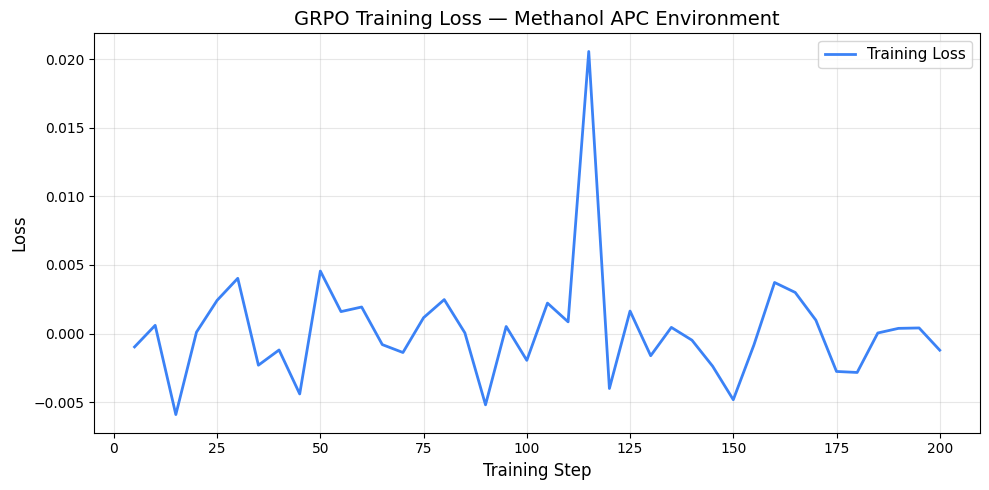

In [8]:
# --- Extract training logs ---
log_history = trainer.state.log_history
steps = [e["step"] for e in log_history if "loss" in e]
losses = [e["loss"] for e in log_history if "loss" in e]

# --- Plot 1: Loss Curve ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, losses, color="#3b82f6", linewidth=2, label="Training Loss")
ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("GRPO Training Loss — Methanol APC Environment", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/loss_curve.png", dpi=150, bbox_inches="tight")
print(f"Saved: {PLOT_DIR}/loss_curve.png")
plt.show()

In [9]:
# --- Evaluate: Untrained Baseline vs Trained Agent ---
def evaluate_agent(model, tokenizer, task="optimization", num_episodes=5, steps_per_ep=15, label="Agent"):
    """Run the model against the environment and collect per-step rewards."""
    FastLanguageModel.for_inference(model)
    all_rewards = []
    for ep in range(num_episodes):
        env, obs = make_env(task=task, seed=ep * 100)
        ep_rewards = []
        for step in range(steps_per_ep):
            if obs.done:
                break
            sensor_text = obs_to_text(obs)
            prompt = f"{SYSTEM_PROMPT}\n\nSensors:\n{sensor_text}\n\nAction JSON:"
            inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
            with torch.no_grad():
                outputs = model.generate(
                    **inputs, max_new_tokens=150, temperature=0.3,
                    do_sample=True, pad_token_id=tokenizer.eos_token_id
                )
            response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            try:
                action_dict = json.loads(response.strip().split("\n")[0])
                action = MethanolAPCAction(**action_dict)
                obs = env.step(action)
                ep_rewards.append(float(obs.reward))
            except Exception:
                # Fallback: safe conservative action
                obs = env.step(MethanolAPCAction(
                    feed_rate_h2=3.0, feed_rate_co=1.5,
                    cooling_water_flow=60.0, compressor_power=50.0))
                ep_rewards.append(float(obs.reward))
        all_rewards.append(ep_rewards)
    # Pad to same length and average
    max_len = max(len(r) for r in all_rewards)
    padded = [r + [r[-1]] * (max_len - len(r)) if r else [0.01] * max_len for r in all_rewards]
    avg_rewards = np.mean(padded, axis=0)
    print(f"{label} [{task}]: avg_reward={np.mean(avg_rewards):.4f}, episodes={num_episodes}")
    return avg_rewards

# --- Run baseline (untrained = random/fallback actions) ---
def evaluate_baseline(task="optimization", num_episodes=5, steps_per_ep=15):
    """Baseline: random actions from the environment's action space."""
    all_rewards = []
    for ep in range(num_episodes):
        env, obs = make_env(task=task, seed=ep * 100)
        ep_rewards = []
        for step in range(steps_per_ep):
            if obs.done:
                break
            action = MethanolAPCAction(
                feed_rate_h2=random.uniform(1, 8),
                feed_rate_co=random.uniform(0.5, 4),
                cooling_water_flow=random.uniform(10, 80),
                compressor_power=random.uniform(20, 80),
            )
            obs = env.step(action)
            ep_rewards.append(float(obs.reward))
        all_rewards.append(ep_rewards)
    max_len = max(len(r) for r in all_rewards)
    padded = [r + [r[-1]] * (max_len - len(r)) if r else [0.01] * max_len for r in all_rewards]
    avg_rewards = np.mean(padded, axis=0)
    print(f"Baseline [{task}]: avg_reward={np.mean(avg_rewards):.4f}")
    return avg_rewards

print("Evaluating baseline (random actions)...")
baseline_rewards = evaluate_baseline("optimization")
print("\nEvaluating trained agent...")
trained_rewards = evaluate_agent(model, tokenizer, "optimization", label="Trained")

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluating baseline (random actions)...
Baseline [optimization]: avg_reward=0.8440

Evaluating trained agent...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1

Trained [optimization]: avg_reward=0.9019, episodes=5


Saved: /content/methanol-apc/training_plots/reward_curve.png


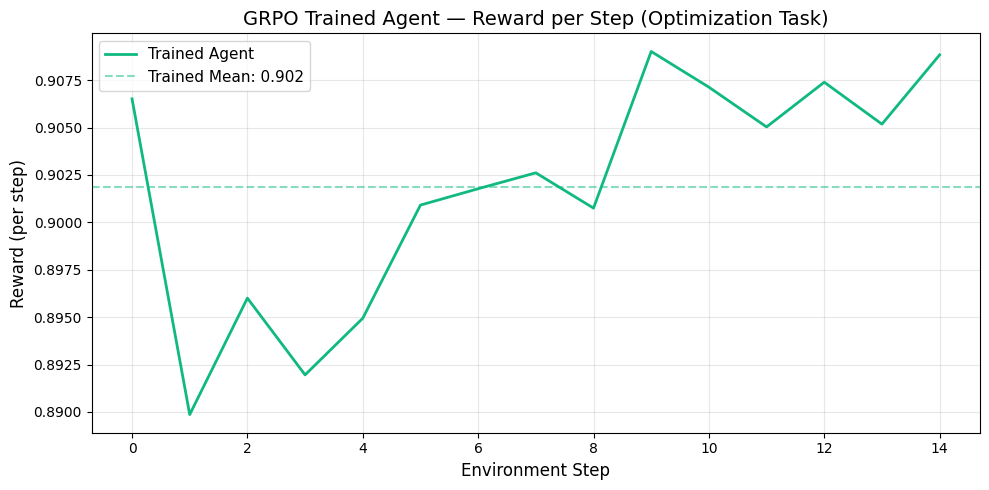

Saved: /content/methanol-apc/training_plots/baseline_vs_trained.png


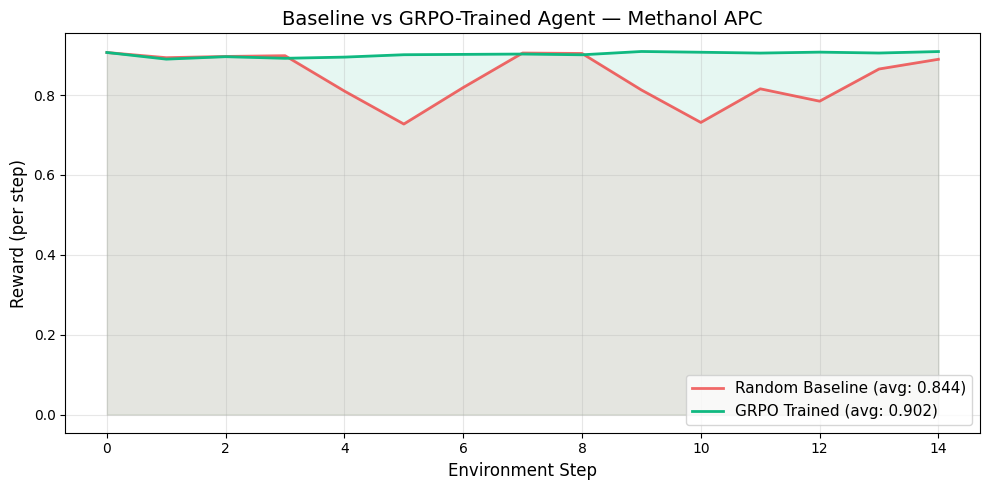


IMPROVEMENT: +0.0579 reward
Baseline avg: 0.8440
Trained avg:  0.9019


In [10]:
# --- Plot 2: Reward Curve (average reward per step during eval) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(trained_rewards)), trained_rewards, color="#10b981", linewidth=2, label="Trained Agent")
ax.axhline(y=np.mean(trained_rewards), color="#10b981", linestyle="--", alpha=0.5, label=f"Trained Mean: {np.mean(trained_rewards):.3f}")
ax.set_xlabel("Environment Step", fontsize=12)
ax.set_ylabel("Reward (per step)", fontsize=12)
ax.set_title("GRPO Trained Agent — Reward per Step (Optimization Task)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/reward_curve.png", dpi=150, bbox_inches="tight")
print(f"Saved: {PLOT_DIR}/reward_curve.png")
plt.show()

# --- Plot 3: Baseline vs Trained ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(baseline_rewards)), baseline_rewards, color="#ef4444", linewidth=2, alpha=0.8, label=f"Random Baseline (avg: {np.mean(baseline_rewards):.3f})")
ax.plot(range(len(trained_rewards)), trained_rewards, color="#10b981", linewidth=2, label=f"GRPO Trained (avg: {np.mean(trained_rewards):.3f})")
ax.fill_between(range(len(baseline_rewards)), baseline_rewards, alpha=0.1, color="#ef4444")
ax.fill_between(range(len(trained_rewards)), trained_rewards, alpha=0.1, color="#10b981")
ax.set_xlabel("Environment Step", fontsize=12)
ax.set_ylabel("Reward (per step)", fontsize=12)
ax.set_title("Baseline vs GRPO-Trained Agent — Methanol APC", fontsize=14)
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/baseline_vs_trained.png", dpi=150, bbox_inches="tight")
print(f"Saved: {PLOT_DIR}/baseline_vs_trained.png")
plt.show()

print(f"\n{'='*50}")
print(f"IMPROVEMENT: {np.mean(trained_rewards) - np.mean(baseline_rewards):+.4f} reward")
print(f"Baseline avg: {np.mean(baseline_rewards):.4f}")
print(f"Trained avg:  {np.mean(trained_rewards):.4f}")
print(f"{'='*50}")

In [11]:
model.save_pretrained("./grpo_methanol_trained")
tokenizer.save_pretrained("./grpo_methanol_trained")
print("Model saved to ./grpo_methanol_trained")

import shutil
for fname in ["loss_curve.png", "reward_curve.png", "baseline_vs_trained.png"]:
    src = f"{PLOT_DIR}/{fname}"
    if os.path.exists(src):
        print(f"Plot ready: {src}")

Unsloth: Restored added_tokens_decoder metadata in ./grpo_methanol_trained/tokenizer_config.json.


Model saved to ./grpo_methanol_trained
Plot ready: /content/methanol-apc/training_plots/loss_curve.png
Plot ready: /content/methanol-apc/training_plots/reward_curve.png
Plot ready: /content/methanol-apc/training_plots/baseline_vs_trained.png
